In [13]:
import re
import numpy as np

def extract_numbers(text: str):
    return [float(x) for x in re.findall(r"\d+(?:\.\d+)?", text)]

def contains_close_number(text: str, target: float, rel_tol=0.25, abs_tol=1e-2):
    nums = extract_numbers(text)
    for n in nums:
        if abs(n - target) <= max(abs_tol, rel_tol * abs(target if target != 0 else 1.0)):
            return True
    return False

def score_feedback(row, feedback: str) -> dict:
    feedback_lower = feedback.lower()

    # ---------- 1. Softer accuracy ----------
    accuracy_points = []

    # A. Numeric grounding (soft)
    # Reward if at least fuel is mentioned correctly, and optionally speed/RPM
    numeric_hits = 0

    if contains_close_number(feedback, float(row["Avg_Fuel_L/100km"]), rel_tol=0.25, abs_tol=0.05):
        numeric_hits += 1

    if contains_close_number(feedback, float(row["Avg_Speed_kmh"]), rel_tol=0.25, abs_tol=2.0):
        numeric_hits += 1

    if contains_close_number(feedback, float(row["Avg_RPM"]), rel_tol=0.25, abs_tol=75.0):
        numeric_hits += 1

    # 0, 1, 2, 3 hits mapped to a softer score
    if numeric_hits == 0:
        accuracy_points.append(0.2)
    elif numeric_hits == 1:
        accuracy_points.append(0.6)
    elif numeric_hits == 2:
        accuracy_points.append(0.85)
    else:
        accuracy_points.append(1.0)

    # B. Issue alignment
    issue_hits = 0
    issue_total = 0

    # idling relevance
    issue_total += 1
    if row["Long_Idle_Time_%"] >= 10:
        if any(w in feedback_lower for w in ["idle", "idling", "stationary", "traffic"]):
            issue_hits += 1
    else:
        if any(w in feedback_lower for w in ["minimal long idling", "low idling", "little idling", "minimal idling"]) \
           or "idling" not in feedback_lower:
            issue_hits += 1

    # rpm relevance
    issue_total += 1
    if row["Avg_RPM"] >= 1500 or row["HighRPM_LowSpeed_%"] > 0:
        if any(w in feedback_lower for w in ["rpm", "gear", "engine", "over-rev", "high rpm"]):
            issue_hits += 1
    else:
        if any(w in feedback_lower for w in ["minimal high rpm", "no high rpm", "absence of high rpm"]) \
           or "high rpm" not in feedback_lower:
            issue_hits += 1

    # accel/brake relevance
    issue_total += 1
    total_events = row["Accel_Events"] + row["Brake_Events"]
    if total_events >= 800:
        if any(w in feedback_lower for w in ["smooth", "accel", "brake", "coast", "steady speed", "anticipate"]):
            issue_hits += 1
    else:
        if any(w in feedback_lower for w in ["smooth", "steady", "consistent"]) or True:
            issue_hits += 1

    issue_alignment_score = issue_hits / issue_total
    accuracy_points.append(issue_alignment_score)

    # C. Contradiction penalty
    contradiction_penalty = 0.0

    if row["Long_Idle_Time_%"] < 3 and "high idling" in feedback_lower:
        contradiction_penalty += 0.2

    if row["HighRPM_LowSpeed_%"] == 0 and "high rpm at low speed" in feedback_lower and "minimal" not in feedback_lower:
        contradiction_penalty += 0.2

    accuracy_score = max(0.0, min(1.0, np.mean(accuracy_points) - contradiction_penalty))

    # ---------- 2. Usefulness ----------
    usefulness_checks = []

    if row["Long_Idle_Time_%"] > 15:
        usefulness_checks.append(any(w in feedback_lower for w in ["idle", "idling", "stationary", "traffic"]))

    if (row["Accel_Events"] + row["Brake_Events"]) > 300:
        usefulness_checks.append(any(w in feedback_lower for w in ["smooth", "accel", "brake", "steady speed", "coast", "anticipate"]))

    if row["Avg_RPM"] > 1500:
        usefulness_checks.append(any(w in feedback_lower for w in ["rpm", "gear", "engine", "shift"]))

    usefulness_score = sum(usefulness_checks) / len(usefulness_checks) if usefulness_checks else 0.7

    # ---------- 3. Clarity ----------
    length_score = max(0.0, min(1.0, len(feedback.split()) / 120))
    bullet_score = 1.0 if re.search(r"^(\s*[-•]|\d+\.)", feedback, flags=re.MULTILINE) else 0.5
    clarity_score = 0.5 * length_score + 0.5 * bullet_score

    # ---------- 4. Safety ----------
    unsafe_keywords = [
        "ignore speed limits",
        "tailgate",
        "drive aggressively",
        "overtake blindly",
    ]
    safety_score = 0.0 if any(k in feedback_lower for k in unsafe_keywords) else 1.0

    # ---------- 5. Overall ----------
    overall_score = float(np.mean([accuracy_score, usefulness_score, clarity_score, safety_score]))

    return {
        "accuracy_score": round(float(accuracy_score), 3),
        "usefulness_score": round(float(usefulness_score), 3),
        "clarity_score": round(float(clarity_score), 3),
        "safety_score": round(float(safety_score), 3),
        "overall_score": round(float(overall_score), 3),
    }

Loaded 75 Granite feedback records


,Trip,feedback,prompt,accuracy_score,usefulness_score,clarity_score,safety_score,overall_score
0,2017-07-10_Seat_Leon_KA_KA_Stau.csv,**Overview:** \nYour driving trip shows a com...,Here is a driving trip summary:\n\n- Average s...,0.925,1.0,1.0,1.0,0.981
1,2017-07-11_Seat_Leon_KA_KA_Stau.csv,**Overview:** \nYour driving trip shows a com...,Here is a driving trip summary:\n\n- Average s...,0.800,1.0,1.0,1.0,0.950
2,2017-07-11_Seat_Leon_KA_S_Normal.csv,**Overview:**\nYour driving trip summary shows...,Here is a driving trip summary:\n\n- Average s...,0.800,1.0,1.0,1.0,0.950
3,2017-07-11_Seat_Leon_S_RT_Frei.csv,**Overview:** \nYour driving trip demonstrate...,Here is a driving trip summary:\n\n- Average s...,0.633,1.0,1.0,1.0,0.908
4,2017-07-12_Seat_Leon_RT_S_Normal.csv,**Overview:** \nYour driving trip demonstrate...,Here is a driving trip summary:\n\n- Average s...,0.633,1.0,1.0,1.0,0.908
...,...,...,...,...,...,...,...,...
70,2018-03-26_Seat_Leon_RT_S_Normal.csv,**Overview:**\nYour driving trip demonstrates ...,Here is a driving trip summary:\n\n- Average s...,0.800,1.0,1.0,1.0,0.950
71,2018-03-26_Seat_Leon_S_RT_Stau.csv,### Overview\nYour driving trip demonstrates a...,Here is a driving trip summary:\n\n- Average s...,0.600,1.0,1.0,1.0,0.900
72,2018-03-29_Seat_Leon_KA_RT_Stau.csv,**Overview:** \nYour driving trip demonstrate...,Here is a driving trip summary:\n\n- Average s...,0.600,1.0,1.0,1.0,0.900
73,2018-04-23_Seat_Leon_KA_KA_Frei.csv,**Overview:**\nYour driving trip summary shows...,Here is a driving trip summary:\n\n- Average s...,0.633,1.0,1.0,1.0,0.908



✅ Evaluated 75 trips.
💾 Saved JSON   → ../data/granite_feedback_evaluation.json
💾 Saved CSV    → ../data/granite_feedback_evaluation.csv


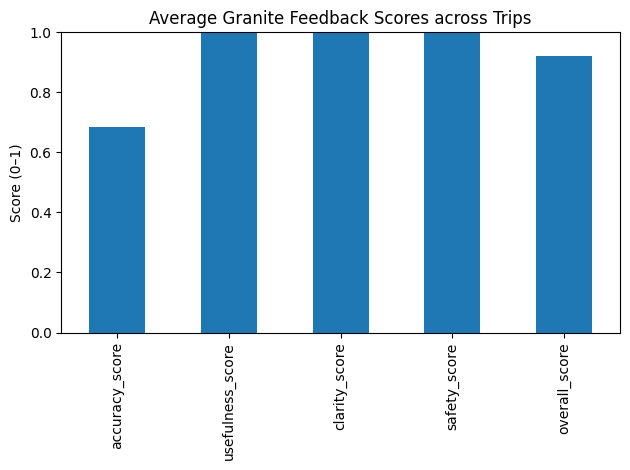

These scores are heuristic proxies rather than ground-truth measures. They are intended to detect gross mismatches, omissions, or unsafe advice at scale, not to evaluate linguistic quality or factual correctness exhaustively.


In [16]:
import json
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path

# --- Load trip summary (ground truth stats) ---
trip_summary_path = Path("../data/trip_summary_stats.csv")
trip_summary = pd.read_csv(trip_summary_path)

# For faster lookup, index by Trip
trip_summary_indexed = trip_summary.set_index("Trip")

# --- Load Granite feedback JSON ---
feedback_path = Path("../data/granite_trip_feedback.json")

with open(feedback_path, "r") as f:
    feedback_records = json.load(f)

print(f"Loaded {len(feedback_records)} Granite feedback records")

# --- Evaluate each feedback ---
evaluated = []

for rec in feedback_records:
    trip_name = rec.get("Trip")
    feedback_text = rec.get("feedback", "")

    if trip_name not in trip_summary_indexed.index:
        print(f"⚠️ Trip '{trip_name}' not found in trip_summary_stats.csv — skipping.")
        continue

    row = trip_summary_indexed.loc[trip_name]

    scores = score_feedback(row, feedback_text)

    evaluated.append({
        "Trip": trip_name,
        "feedback": feedback_text,
        "prompt": rec.get("prompt", ""),
        **scores,
    })


# --- Convert to DataFrame and inspect ---
eval_df = pd.DataFrame(evaluated)
display(eval_df)

print(f"\n✅ Evaluated {len(eval_df)} trips.")


# --- Save to JSON + CSV for later use / UI ---
out_json = Path("../data/granite_feedback_evaluation.json")
out_csv  = Path("../data/granite_feedback_evaluation.csv")

with open(out_json, "w") as f:
    json.dump(evaluated, f, indent=2)

eval_df.to_csv(out_csv, index=False)

print(f"💾 Saved JSON   → {out_json}")
print(f"💾 Saved CSV    → {out_csv}")

eval_df[["accuracy_score", "usefulness_score", "clarity_score", "safety_score", "overall_score"]].mean().plot.bar()

plt.title("Average Granite Feedback Scores across Trips")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"These scores are heuristic proxies rather than ground-truth measures. They are intended to detect gross mismatches, omissions, or unsafe advice at scale, not to evaluate linguistic quality or factual correctness exhaustively."
)

